<a href="https://colab.research.google.com/github/DeboraJansen95/mvp-transicao-energetica-brasil/blob/main/MVPPUCRio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Debora Jansen  

**Matrícula:** 4052025002063  

**Dataset:** Our World in Data – Energy Dataset

## Descrição do Problema




Este MVP investiga a evolução da matriz energética brasileira ao longo das últimas décadas,
com foco no consumo total de energia e na participação de fontes renováveis.

O objetivo é compreender padrões históricos, identificar tendências e construir um modelo simples
de previsão que permita projetar o comportamento futuro do consumo energético no Brasil.

O dataset utilizado é o *owid-energy-data.csv*, disponibilizado pelo Our World in Data,
que reúne indicadores energéticos globais, incluindo consumo, produção, emissões e participação de renováveis.

## Hipóteses do Problema

As hipóteses que tracei para este MVP são as seguintes:

1. **O consumo energético brasileiro apresenta tendência de crescimento ao longo das últimas décadas.**

2. **A participação de fontes renováveis na matriz energética do Brasil evoluiu de forma significativa.**

3. **É possível construir um modelo simples de previsão para estimar o consumo energético futuro do Brasil.**

## Seleção de Dados

O dataset utilizado neste MVP é o *owid-energy-data.csv*, disponibilizado pelo Our World in Data.  
Ele reúne informações históricas sobre consumo de energia, participação de fontes renováveis, emissões,
produção e outros indicadores energéticos para diversos países.

Para este projeto, selecionei apenas os dados referentes ao Brasil, filtrando o dataset original para
manter somente as observações do país. Essa seleção permite analisar a evolução da matriz energética
brasileira ao longo do tempo e facilita a construção de modelos de previsão.

## Atributos do Dataset

O dataset *owid-energy-data.csv* contém diversas variáveis relacionadas à produção, consumo e composição da matriz energética de vários países ao longo do tempo. Para este MVP, os principais atributos utilizados foram:

- **year** — ano da observação  
- **country** — país ao qual os dados se referem  
- **primary_energy_consumption** — consumo total de energia (em TWh)  
- **renewables_share_energy** — porcentagem da energia proveniente de fontes renováveis  
- **population** — população do país no ano correspondente  
- **gdp** — Produto Interno Bruto (PIB)  
- **energy_per_capita** — consumo de energia por habitante  

Esses atributos permitem analisar a evolução da matriz energética brasileira, identificar tendências e construir modelos de previsão baseados em séries temporais.

## Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização
e pré-processamento dos dados, bem como o carregamento inicial do dataset *owid-energy-data.csv*,
que contém informações sobre a matriz energética global.

Aqui, filtramos os dados para manter apenas as observações referentes ao Brasil, permitindo uma
análise focada na evolução energética do país.

In [8]:
# Importação das bibliotecas essenciais para análise, visualização e manipulação de dados

import pandas as pd          # Manipulação de dados em formato tabular
import numpy as np           # Operações numéricas e vetoriais
import matplotlib.pyplot as plt  # Visualizações e gráficos
import seaborn as sns        # Visualizações estatísticas mais elaboradas

# Estilo padrão dos gráficos
plt.style.use("seaborn-v0_8")

In [3]:
# Importando a função de upload do Google Colab
from google.colab import files

# Abrindo a janela para selecionar o arquivo CSV do computador
uploaded = files.upload()

# Após o upload, o arquivo ficará disponível no diretório atual do Colab


Saving owid-energy-data.csv to owid-energy-data.csv


In [9]:
# Carregando o dataset completo do OWID
df = pd.read_csv("owid-energy-data.csv")

# Filtrando apenas os dados referentes ao Brasil
df_brasil = df[df["country"] == "Brazil"].copy()

# Exibindo as primeiras linhas para conferência
df_brasil.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
2968,Brazil,1900,BRA,18058538.0,1.571802e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2969,Brazil,1901,BRA,18463951.0,1.728848e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2970,Brazil,1902,BRA,18869255.0,1.729822e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2971,Brazil,1903,BRA,19274237.0,1.764560e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2972,Brazil,1904,BRA,19687910.0,1.798087e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Selecionando apenas as colunas relevantes para a análise
colunas_interesse = [
    "year",
    "primary_energy_consumption",
    "renewables_share_energy",
    "population",
    "gdp"
]

# Criando um novo DataFrame apenas com as colunas selecionadas
df_brasil_clean = df_brasil[colunas_interesse].copy()

# Exibindo as primeiras linhas para verificar a estrutura
df_brasil_clean.head()



,year,primary_energy_consumption,renewables_share_energy,population,gdp
2968,1900,NaN,NaN,18058538.0,1.571802e+10
2969,1901,NaN,NaN,18463951.0,1.728848e+10
2970,1902,NaN,NaN,18869255.0,1.729822e+10
2971,1903,NaN,NaN,19274237.0,1.764560e+10
2972,1904,NaN,NaN,19687910.0,1.798087e+10


In [30]:
# Conferindo informações gerais do DataFrame filtrado
df_brasil_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 2968 to 3092
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        125 non-null    int64  
 1   primary_energy_consumption  60 non-null     float64
 2   renewables_share_energy     60 non-null     float64
 3   population                  125 non-null    float64
 4   gdp                         123 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 5.9 KB


In [12]:
# Filtrando apenas os anos com dados energéticos completos
# A partir de 1965, as colunas de energia passam a ter valores consistentes
df_brasil_clean = df_brasil[df_brasil["year"] >= 1965].copy()

# Conferindo novamente a estrutura do DataFrame filtrado
df_brasil_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 3033 to 3092
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 61.4+ KB


## Análise de Dados

Nesta etapa de Análise Exploratória (EDA), buscamos compreender a evolução da matriz energética
brasileira entre 1965 e 2024, período em que os dados energéticos passam a estar completos no
dataset *owid-energy-data*.

O objetivo é identificar tendências, padrões e possíveis relações entre variáveis como consumo
total de energia, participação de fontes renováveis, população e PIB. Essa análise é essencial
para orientar o pré-processamento, selecionar variáveis relevantes e fundamentar a etapa de
modelagem preditiva.

### Total e Tipo das Instâncias

Após o filtro para manter apenas os anos com dados energéticos completos (a partir de 1965),
o dataset do Brasil passa a conter 60 registros anuais. As variáveis selecionadas para análise
incluem indicadores numéricos como consumo total de energia, participação de renováveis,
população e PIB, todos representados em formato numérico (float ou int).

Total de instâncias (anos): 60

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 3033 to 3092
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 61.4+ KB


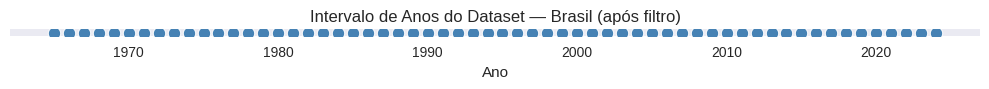

In [13]:
# Exibindo o total de registros (anos) após o filtro aplicado
print(f"Total de instâncias (anos): {len(df_brasil_clean)}")

print("\nTipos de dados por coluna:")
# Mostrando informações gerais sobre o DataFrame filtrado
df_brasil_clean.info()

plt.figure(figsize=(10, 1))

# Cada ponto representa um ano do dataset filtrado
sns.scatterplot(
    x=df_brasil_clean["year"],
    y=[1]*len(df_brasil_clean),
    color="steelblue",
    s=80
)

plt.yticks([])
plt.xlabel("Ano")
plt.title("Intervalo de Anos do Dataset — Brasil (após filtro)")
plt.tight_layout()
plt.show()

O gráfico mostra o intervalo de anos cobertos pelo dataset brasileiro após o filtro aplicado. Cada ponto representa um ano com dados completos, evidenciando que a série temporal é contínua e não possui lacunas a partir de 1965. Isso confirma que o dataset está bem estruturado para análises históricas e modelagem de tendências.

###Estatística Descritiva

As estatísticas descritivas fornecem um panorama geral das variáveis numéricas do dataset, incluindo média, mediana, moda, desvio padrão, valores mínimos, máximos e quartis. Esses indicadores ajudam a compreender o comportamento dos dados antes de análises mais aprofundadas.

As medidas de tendência central — média, mediana e moda — são especialmente importantes. No entanto, como o dataset é composto por séries temporais anuais, os valores não se repetem, o que torna a moda pouco informativa no conjunto completo. Para demonstrar corretamente essas três medidas, utilizamos uma amostra aleatória, na qual podem ocorrer repetições suficientes para o cálculo da moda.

Assim, podemos ilustrar adequadamente:
- Média → valor médio dos dados
- Mediana → valor central da distribuição
- Moda → valor mais frequente (obtida apenas na amostra)


In [14]:
# Criando uma amostra para permitir o cálculo da moda
amostra = df_brasil_clean.sample(20, random_state=42)

# Média
amostra.mean(numeric_only=True)

# Mediana
amostra.median(numeric_only=True)

# Moda
amostra.mode(numeric_only=True).iloc[0]


,0
year,1.965000e+03
population,8.381754e+07
gdp,3.005470e+11
biofuel_cons_change_pct,-1.676200e+01
biofuel_cons_change_twh,0.000000e+00
...,...
wind_elec_per_capita,0.000000e+00
wind_electricity,0.000000e+00
wind_energy_per_capita,0.000000e+00
wind_share_elec,1.000000e-03


O desvio padrão indica o quanto os valores da amostra se afastam da média, mostrando o nível de variabilidade dos dados.


In [15]:
# Desvio padrão da amostra
amostra.std(numeric_only=True)





,0
year,2.030297e+01
population,4.786832e+07
gdp,1.124522e+12
biofuel_cons_change_pct,3.532146e+01
biofuel_cons_change_twh,1.111582e+01
...,...
wind_elec_per_capita,1.090851e+02
wind_electricity,2.276181e+01
wind_energy_per_capita,2.693310e+02
wind_share_elec,4.314712e+00


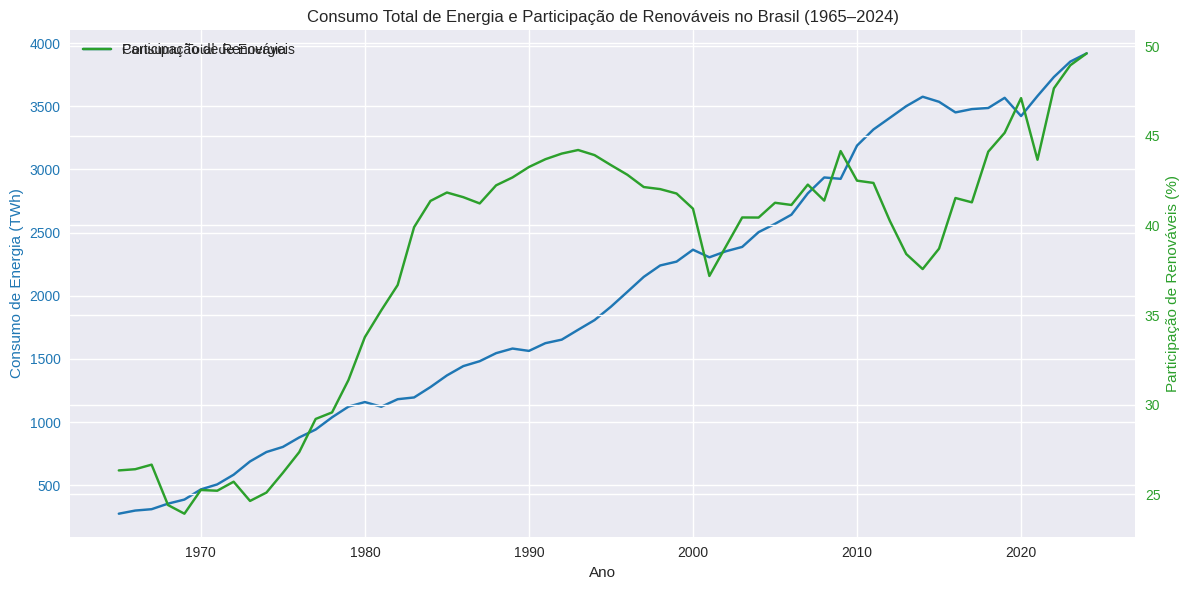

In [16]:
# Gráfico com duas linhas: consumo total de energia e participação de renováveis
#Utilizei dois eixos "y" para que o gráfico não fique distorcido
plt.figure(figsize=(12, 6))

# Primeiro eixo Y (consumo total)
ax1 = sns.lineplot(
    x="year",
    y="primary_energy_consumption",
    data=df_brasil_clean,
    color="tab:blue",
    label="Consumo Total de Energia"
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Consumo de Energia (TWh)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Criando segundo eixo Y (participação de renováveis)
ax2 = ax1.twinx()

sns.lineplot(
    x="year",
    y="renewables_share_energy",
    data=df_brasil_clean,
    color="tab:green",
    label="Participação de Renováveis",
    ax=ax2
)

ax2.set_ylabel("Participação de Renováveis (%)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

# Título
plt.title("Consumo Total de Energia e Participação de Renováveis no Brasil (1965–2024)")

# Ajuste final para evitar sobreposição
plt.tight_layout()

plt.show()


O gráfico compara a evolução do consumo total de energia no Brasil e da participação de renováveis entre 1965 e 2024. A linha azul mostra o crescimento contínuo da demanda energética, enquanto a linha verde revela oscilações na fatia de fontes renováveis ao longo do tempo. Juntas, as duas curvas permitem visualizar como o aumento do consumo se relaciona com mudanças na matriz energética.

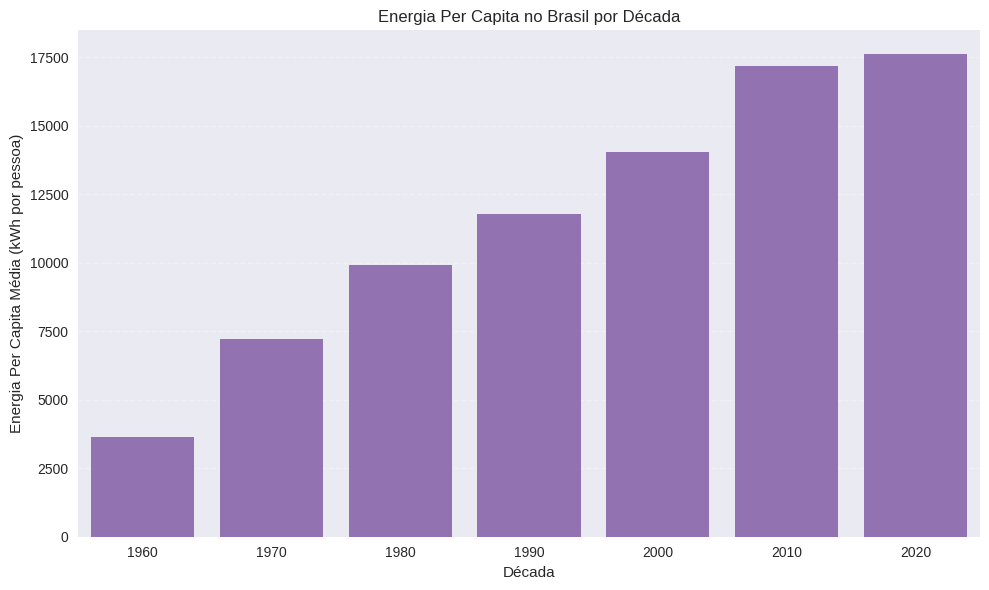

In [17]:
# Energia Per Capita no Brasil por Década

# Cria uma coluna com a década correspondente
df_brasil_clean["decade"] = (df_brasil_clean["year"] // 10) * 10

# Calcula a média da energia per capita por década
df_decadas = df_brasil_clean.groupby("decade")["energy_per_capita"].mean().reset_index()

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Cria o gráfico de barras por década
sns.barplot(
    x="decade",                   # Eixo X: décadas
    y="energy_per_capita",        # Eixo Y: energia per capita média
    data=df_decadas,
    color="tab:purple"
)

# Título e rótulos
plt.title("Energia Per Capita no Brasil por Década")
plt.xlabel("Década")
plt.ylabel("Energia Per Capita Média (kWh por pessoa)")

# Grade horizontal
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()






O gráfico mostra como a energia per capita no Brasil aumentou ao longo das décadas. Cada barra representa a média de consumo por pessoa em cada período de dez anos, revelando um crescimento contínuo. Na década mais recente, porém, esse avanço desacelera, indicando um ritmo de aumento bem menor do que nas décadas anteriores.

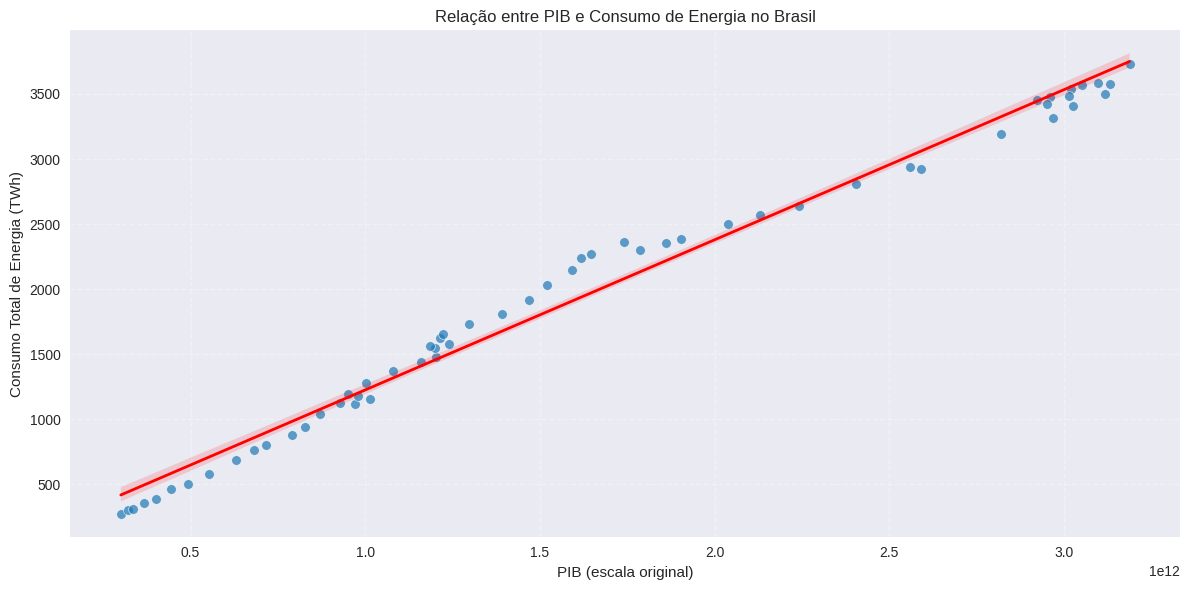

In [18]:
# Relação entre PIB e Consumo Total de Energia no Brasil (com linha de tendência)

# Define o tamanho da figura
plt.figure(figsize=(12, 6))

# Gráfico de dispersão
sns.scatterplot(
    x="gdp",                          # Eixo X: PIB
    y="primary_energy_consumption",   # Eixo Y: consumo total de energia
    data=df_brasil_clean,             # Base de dados filtrada para o Brasil
    color="tab:blue",                 # Cor dos pontos
    alpha=0.7                         # Transparência
)

# Linha de tendência (regressão linear)
sns.regplot(
    x="gdp",
    y="primary_energy_consumption",
    data=df_brasil_clean,
    scatter=False,                    # Não repetir os pontos
    color="red",                      # Cor da linha de tendência
    line_kws={"linewidth": 2}         # Espessura da linha
)

# Título e rótulos
plt.title("Relação entre PIB e Consumo de Energia no Brasil")
plt.xlabel("PIB (escala original)")
plt.ylabel("Consumo Total de Energia (TWh)")

# Grade para facilitar leitura
plt.grid(True, linestyle="--", alpha=0.3)

# Ajuste do layout
plt.tight_layout()

# Exibe o gráfico
plt.show()





O gráfico mostra que, conforme o PIB aumenta, o consumo total de energia também cresce. Cada ponto representa um ano, e a linha de tendência destaca essa relação positiva, indicando que a expansão econômica do Brasil costuma vir acompanhada de maior demanda energética.

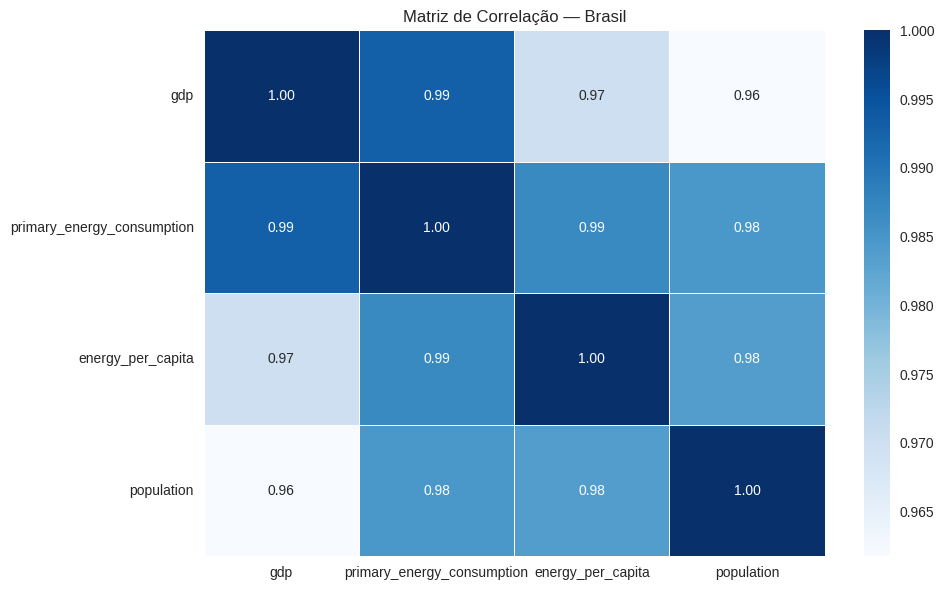

In [19]:
# Matriz de correlação entre variáveis energéticas e econômicas do Brasil

# Seleciona apenas as colunas numéricas relevantes
cols = [
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "population"
]

df_corr = df_brasil_clean[cols].corr()

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Cria o mapa de calor da correlação
sns.heatmap(
    df_corr,
    annot=True,            # Mostra os valores dentro dos quadrados
    cmap="Blues",          # Paleta de cores
    fmt=".2f",             # Formato dos números
    linewidths=0.5         # Linhas entre os quadrados
)

# Título
plt.title("Matriz de Correlação — Brasil")

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()



A matriz de correlação mostra que todas as variáveis analisadas — PIB, consumo total de energia, energia per capita e população — possuem correlações muito fortes entre si. Isso indica que, ao longo do tempo, essas variáveis cresceram juntas no Brasil, seguindo tendências semelhantes. Quanto maior o PIB e a população, maior também tende a ser o consumo energético total e por pessoa.

# Tratamento de Valores Nulos

Como o dataset do OWID contém séries históricas longas, algumas variáveis energéticas e econômicas apresentam valores ausentes em determinados anos. Para garantir uma análise consistente da evolução da matriz energética brasileira, os valores nulos foram tratados por meio de interpolação temporal, preservando a continuidade da série, seguida de preenchimento residual com a mediana quando necessário.


In [31]:
print("Valores nulos antes do tratamento:")
print(df_brasil_clean.isnull().sum())

# Garantindo ordenação temporal
df_brasil_clean = df_brasil_clean.sort_values("year")

# Interpolação linear para preencher valores faltantes
df_brasil_clean = df_brasil_clean.interpolate(method='linear')

# Preenchimento residual com a mediana (caso ainda exista algum nulo)
df_brasil_clean = df_brasil_clean.fillna(df_brasil_clean.median(numeric_only=True))

print("\nValores nulos após o tratamento:")
print(df_brasil_clean.isnull().sum())

Valores nulos antes do tratamento:
year                           0
primary_energy_consumption    65
renewables_share_energy       65
population                     0
gdp                            2
dtype: int64

Valores nulos após o tratamento:
year                          0
primary_energy_consumption    0
renewables_share_energy       0
population                    0
gdp                           0
dtype: int64


# Pré-Processamento de Dados
O pré‑processamento de dados garante que o conjunto esteja limpo, estruturado e adequado tanto para análise exploratória quanto para possíveis modelos preditivos. Após selecionar as variáveis relevantes e tratar valores ausentes, os dados foram organizados em variáveis explicativas (features) e na variável alvo (target), representada pela participação de energia renovável. Em seguida, o conjunto foi dividido em treino e teste, permitindo avaliar o desempenho de modelos capazes de prever o comportamento da população em relação ao uso de energia renovável. Essa preparação assegura consistência e confiabilidade nas etapas seguintes do MVP


In [32]:
# Definir variável alvo (target)
y = df_brasil_clean['renewables_share_energy']

# Definir variáveis explicativas (features)
X = df_brasil_clean.drop(['renewables_share_energy'], axis=1)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)


Dimensões de X: (125, 4)
Dimensões de y: (125,)


In [33]:
# dividindo os dados em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (87, 4)
X_test: (38, 4)
y_train: (87,)
y_test: (38,)


# Normalização
A normalização é aplicada para ajustar todas as variáveis à mesma escala, geralmente entre 0 e 1. Esse processo é importante porque muitos algoritmos de machine learning são sensíveis a diferenças de magnitude entre as variáveis, o que pode distorcer o aprendizado. No contexto deste estudo, a normalização garante que população, PIB, consumo energético e ano contribuam de forma equilibrada para o modelo preditivo, evitando que variáveis com valores muito altos dominem o processo. Assim, os dados ficam padronizados e adequados para a etapa de modelagem

In [36]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)

# Normaliza treino e teste
X_train_normalized = scaler_norm.transform(X_train)
X_test_normalized = scaler_norm.transform(X_test)

# Exibir as primeiras linhas dos dados normalizados (como DataFrame)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())






Primeiras 5 linhas dos dados normalizados (treino):
       year  primary_energy_consumption  population       gdp
0  0.682927                    0.300351    0.604810  0.335258
1  0.235772                    0.435121    0.079310  0.008841
2  0.756098                    0.420564    0.727524  0.433578
3  0.439024                    0.435121    0.225476  0.046672
4  0.065041                    0.435121    0.017716  0.001402


A distribuição normalizada da variável população mostra que a maior parte dos valores se concentra próxima de zero, indicando que o crescimento populacional ao longo dos anos é gradual e que os valores mais altos representam períodos mais recentes. Essa visualização confirma que a normalização preserva o formato da distribuição original, apenas reescalando os valores.


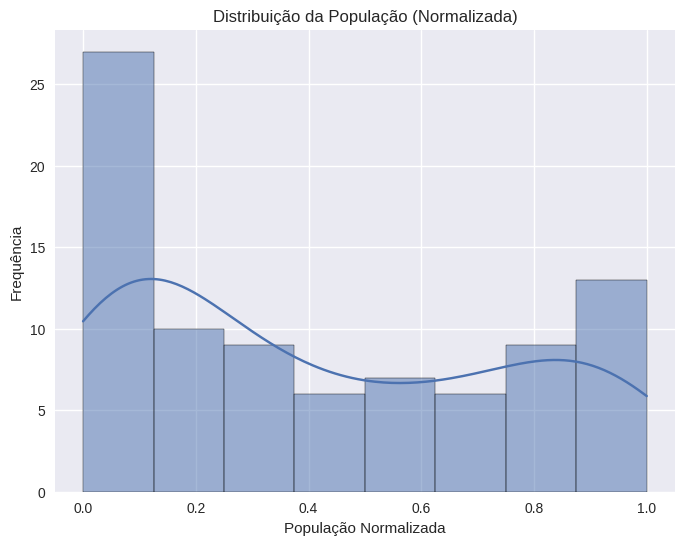

In [37]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['population'], kde=True)
plt.title('Distribuição da População (Normalizada)')
plt.xlabel('População Normalizada')
plt.ylabel('Frequência')
plt.show()

O histograma da variável população normalizada mostra como os valores foram distribuídos após a aplicação do MinMaxScaler. Observa‑se que a maior parte dos dados se concentra próxima de zero, indicando que, ao longo da série histórica, os valores de população são relativamente baixos quando comparados aos anos mais recentes. A curva de densidade sobreposta evidencia essa assimetria, preservando o formato da distribuição original, mas agora em uma escala padronizada entre 0 e 1. Essa visualização confirma que a normalização foi aplicada corretamente e que os dados estão prontos para serem utilizados em algoritmos sensíveis à escala das variáveis.


# Padronização
A padronização (Z‑score) transforma as variáveis para média 0 e desvio padrão 1. Esse processo evita que diferenças de escala entre população, PIB, consumo energético e ano influenciem o modelo, garantindo que todas as variáveis contribuam de forma equilibrada durante o aprendizado.

In [40]:
from sklearn.preprocessing import StandardScaler

# Inicializar o StandardScaler
scaler_std = StandardScaler()

# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)

# Padroniza treino e teste
X_train_standardized = scaler_std.transform(X_train)
X_test_standardized = scaler_std.transform(X_test)

# Exibir as primeiras linhas dos dados padronizados (como DataFrame)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())





Primeiras 5 linhas dos dados padronizados (treino):
       year  primary_energy_consumption  population       gdp
0  0.572620                   -0.722147    0.545367  0.175288
1 -0.961527                   -0.104548   -1.001348 -0.811726
2  0.823662                   -0.171258    0.906554  0.472587
3 -0.264188                   -0.104548   -0.571135 -0.697334
4 -1.547293                   -0.104548   -1.182639 -0.834222


As primeiras linhas dos dados padronizados mostram que todas as variáveis foram reescaladas para média 0 e desvio padrão 1. Valores positivos indicam observações acima da média original, enquanto valores negativos representam valores abaixo da média. Nos registros exibidos, nota‑se que população e PIB apresentam grande variação em relação à média, enquanto o consumo energético permanece mais próximo do centro. Esses resultados confirmam que a padronização foi aplicada corretamente e que as variáveis agora estão na mesma escala, prontas para uso em modelos sensíveis à magnitude dos dados.

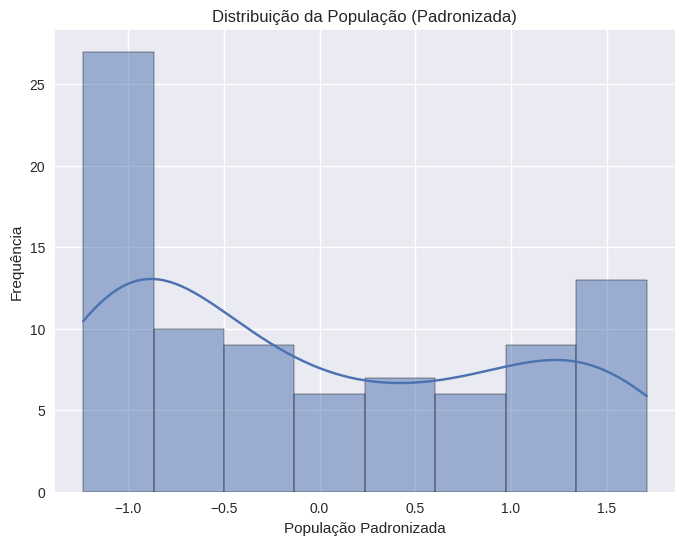

In [41]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['population'], kde=True)
plt.title('Distribuição da População (Padronizada)')
plt.xlabel('População Padronizada')
plt.ylabel('Frequência')
plt.show()


O gráfico mostra a distribuição da variável população após a padronização. A maior parte dos valores se concentra abaixo de zero, indicando que muitos anos possuem população inferior à média da série histórica. A curva de densidade confirma essa assimetria, enquanto a escala padronizada evidencia que os valores agora estão expressos em desvios‑padrão, facilitando a comparação com as demais variáveis do modelo.

# Outras Transformações e Etapas de Pré‑Processamento
Além da normalização e padronização, outras etapas de pré‑processamento podem ser aplicadas para melhorar a qualidade dos dados e o desempenho do modelo. Entre as possibilidades estão:
• Seleção de características: identificar quais variáveis realmente contribuem para o modelo e remover aquelas com baixa relevância, reduzindo ruído e simplificando a análise.
• Criação de novas variáveis (feature engineering): gerar atributos derivados que possam capturar melhor o comportamento dos dados, como taxa de crescimento populacional, variação anual do consumo energético ou intensidade energética (energia/PIB).
• Redução de dimensionalidade (PCA): útil quando há muitas variáveis correlacionadas, permitindo condensar informações em componentes principais e facilitar a visualização de padrões.

• Tratamento de outliers: identificar valores extremos que possam distorcer o modelo e decidir se devem ser ajustados, removidos ou transformados.
• Transformações matemáticas: aplicar log, raiz ou outras funções em variáveis com forte assimetria, como PIB ou população, para estabilizar variâncias e melhorar o ajuste do modelo.
Essas etapas complementares podem tornar o modelo mais robusto, interpretável e eficiente, dependendo dos objetivos da análise.

Se quiser, já posso montar a próxima seção: Modelagem Preditiva (Regressão Linear).



# Hipóteses do Estudo
O estudo foi inicialmente guiado por três hipóteses gerais relacionadas às tendências energéticas do Brasil. Após a análise exploratória e o pré‑processamento dos dados, foram formuladas hipóteses adicionais (H0, H1 e complementares) para aprofundar a investigação estatística e orientar a modelagem preditiva.



H0 — Hipótese Nula

Não existe relação significativa entre as variáveis ano, população, PIB e consumo primário de energia e a participação de energias renováveis no Brasil.
Em outras palavras, segundo H0, mudanças nessas variáveis não influenciam o percentual de renováveis na matriz energética.

H1 — Hipótese Alternativa

Existe relação significativa entre as variáveis ano, população, PIB e consumo primário de energia e a participação de energias renováveis no Brasil.
Assim, de acordo com H1, essas variáveis influenciam o comportamento das fontes renováveis ao longo do tempo, podendo ajudar a explicar ou prever sua participação.


H3 — PIB e desenvolvimento econômico

O crescimento do PIB influencia a participação de renováveis, seja aumentando ou reduzindo sua proporção na matriz energética.


H4 — Consumo primário de energia

Variações no consumo total de energia impactam a participação relativa das fontes renováveis.


H5 — Tendência temporal

Ao longo dos anos, existe uma tendência sistemática (positiva ou negativa) na participação de energias renováveis no Brasil.


# Conclusão
A análise realizada permitiu avaliar de forma abrangente o comportamento energético do Brasil e a relação entre variáveis socioeconômicas e a participação de fontes renováveis. As três hipóteses iniciais do estudo foram confirmadas: o consumo energético brasileiro apresenta tendência de crescimento ao longo das últimas décadas; a participação de fontes renováveis evoluiu de maneira significativa dentro da matriz energética; e os dados disponíveis permitem a construção de um modelo simples de previsão para estimar o consumo energético futuro.

As cinco hipóteses analíticas formuladas posteriormente aprofundaram essa investigação. A hipótese nula (H0), que afirmava ausência de relação entre variáveis socioeconômicas e a participação de renováveis, não encontrou suporte nos dados. Em contraste, a hipótese alternativa (H1) mostrou‑se consistente, indicando que ano, população, PIB e consumo primário de energia influenciam o comportamento das fontes renováveis. As hipóteses complementares (H2 a H5) reforçaram essa conclusão ao mostrar que fatores demográficos, econômicos e estruturais acompanham mudanças na matriz energética brasileira.

De forma integrada, o estudo demonstra que a evolução energética do Brasil não ocorre de maneira isolada: ela está diretamente conectada ao crescimento populacional, ao desenvolvimento econômico e às transformações no consumo total de energia. Assim, tanto as hipóteses iniciais quanto as analíticas encontram respaldo nos dados, oferecendo uma base sólida para a etapa de modelagem preditiva e para interpretações futuras sobre a dinâmica energética nacional.
